<a href="https://colab.research.google.com/github/kiteve/Kiteve/blob/main/Python_project(Sejong_bus)_20250429.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis of Sejong city's public bus usage in 2024**

**1. Research question:** How can Sejong City improve its public bus services?

To address this question, this study analyzes 2024 bus usage data in Sejong City to identify patterns by time and region, and to examine correlations with various regional indicators.

**2. Sources for data**

1) Sejong City Big Data Platform: 2024 bus card transaction records, Sejong City bus routes, etc.

2) Public Data Portal: Information by district (dong) in Sejong City, including demographics and household data

3) Open Meteorological Data Portal: Daily weather information

4) Github: GeoJSON file

# 1. Initial data processing


In [ ]:
import pandas as pd # data control
import seaborn as sns
import numpy as np # data type
import matplotlib.pyplot as plt #line chart (visualization, plot)
import folium  # map control
from IPython.display import display # google map direct
import plotly.express as px # bubble chart
import random #word cloud
from wordcloud import WordCloud #word cloud
import matplotlib as mpl # for configuring settings(e.g. font)
import matplotlib.font_manager as fm

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


(Codes to Fix Korean-character encoding issue)

In [ ]:
#Korean Font issues resolved

!apt-get -qq install -y fonts-nanum  # korean font nanum godic

# Specify font path
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# Manually register the font
fm.fontManager.addfont(font_path)

# Get the exact font name
font_name = fm.FontProperties(fname=font_path).get_name()
print("Font name:", font_name)

# Force set font globally
plt.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

# Set font by name again (redundant but safe)
plt.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Font name: NanumGothic


(Reading the target file)

In [ ]:
# Set file path
f_folder = "drive/MyDrive/Python/"

f_name1 = "bus_use_2024_all.csv"
f_path1 = f_folder + f_name1

f_name2 = "station.csv"
f_path2 = f_folder + f_name2

f_name3 = "route.csv"
f_path3 = f_folder + f_name3

f_name4 = "weather.csv"
f_path4 = f_folder + f_name4

f_name5 = "fine dust.csv"
f_path5 = f_folder + f_name5

f_name6 = "Sejong District-level information2.csv"
f_path6 = f_folder + f_name6

(Using Pandas)

In [ ]:
# <Read the file using pandas>

# 1.Bus ridership data for 2024 : Data type specification(Type assignment error in pandas)
bus_df = pd.read_csv(f_path1, dtype={'brd_deal_dt': 'string',  'card_brd_tm': 'string',
                                     'user_dvs_cd': np.int8,   'card_brd_sttn_id': 'string', 'card_alit_sttn_id': 'string',
                                     'alit_deal_dt': 'string', 'alit_deal_tm': 'string',     'user_cnt': np.int32,
                                     'card_rout_cd':'string'})

# 2.mapping data(bus station) : Data type specification(Type assignment error in pandas),  Encoding for KOREAN
st_df = pd.read_csv(f_path2, encoding='euc-kr', dtype = {'station_code':'string'})

# 3.mapping data(bus routes)  : Data type specification(Type assignment error in pandas),  Encoding for KOREAN
rt_df = pd.read_csv(f_path3, encoding='euc-kr', dtype = {'route_code':'string'})

# 4.weather/day : Encoding for KOREAN
wt_df = pd.read_csv(f_path4, encoding='euc-kr')

# 5.fine dust/ug/m3/day : Encoding for KOREAN
fd_df = pd.read_csv(f_path5, encoding='euc-kr')

In [ ]:
bus_df.head()

,brd_deal_dt,card_brd_tm,trsf_cnt,user_dvs_cd,card_brd_sttn_id,card_alit_sttn_id,alit_deal_dt,alit_deal_tm,user_cnt,brd_amt,alit_amt,card_rout_cd
0,20240131,235041,0,1,6801844,6806246,20240201,000816,1,1400,0,60600130
1,20240131,235042,0,1,6801062,6801875,20240131,235859,1,1400,0,60600087
2,20240131,235045,0,1,6801062,6801875,20240131,235902,1,1400,0,60600087
3,20240131,235046,0,1,6801062,6801149,20240131,235814,1,1400,0,60600087
4,20240131,235048,0,1,6801062,6801149,20240131,235813,1,1400,0,60600087


In [ ]:
bus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19569158 entries, 0 to 19569157
Data columns (total 12 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   brd_deal_dt        string
 1   card_brd_tm        string
 2   trsf_cnt           int64 
 3   user_dvs_cd        int8  
 4   card_brd_sttn_id   string
 5   card_alit_sttn_id  string
 6   alit_deal_dt       string
 7   alit_deal_tm       string
 8   user_cnt           int32 
 9   brd_amt            int64 
 10  alit_amt           int64 
 11  card_rout_cd       string
dtypes: int32(1), int64(3), int8(1), string(7)
memory usage: 1.5 GB


# 2. User Type & Time-based Bus Usage

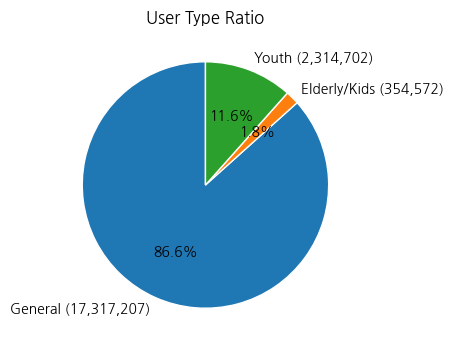

In [ ]:
# Aggregation by user type
usetype = bus_df.groupby('user_dvs_cd')['user_cnt'].sum().reset_index()
label_map = {1: 'General', 2: 'Elderly/Kids', 4: 'Youth'}   # converting the user type number to readable text labels
usetype['label'] = usetype['user_dvs_cd'].map(label_map)
usetype['label_with_cnt'] = usetype.apply(lambda row: f"{row['label']} ({row['user_cnt']:,})", axis=1) # creating a string "label (count)"

# User type Pie chart visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))  # adjusting the size
ax.set_title('User Type Ratio')
ax.pie(
    usetype['user_cnt'],
    labels=usetype['label_with_cnt'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.show()

In [ ]:
# data processing : Convert hours, minutes, and seconds to hours (hour e.g. "220101" >> "22")
bus_df['card_brd_tm'] = bus_df['card_brd_tm'].astype(str).str[:2]
bus_df['alit_deal_tm'] = bus_df['alit_deal_tm'].astype(str).str[:2]

# data processing : Convert string to datetime for data calculation and filtering
bus_df['brd_deal_dt'] = pd.to_datetime(bus_df['brd_deal_dt'], format='%Y%m%d')
bus_df['alit_deal_dt'] = pd.to_datetime(bus_df['alit_deal_dt'], format='%Y%m%d')
wt_df['date'] = pd.to_datetime(wt_df['date'])
fd_df['date'] = pd.to_datetime(fd_df['date'], format='%Y%m%d')

# data processing : Add month(1~12), weekday(0:mon ~ 6:sun), weekday_chk(weekday, weekend)   (using brd_deal_dt)
bus_df['month'] = bus_df['brd_deal_dt'].dt.month.astype('int8')
bus_df['weekday_num'] = bus_df['brd_deal_dt'].dt.dayofweek.astype('int8')
bus_df['weekday_chk'] = bus_df['weekday_num'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
bus_df['weekday_chk'] = bus_df['weekday_chk'].astype('category')



**(Hourly)**

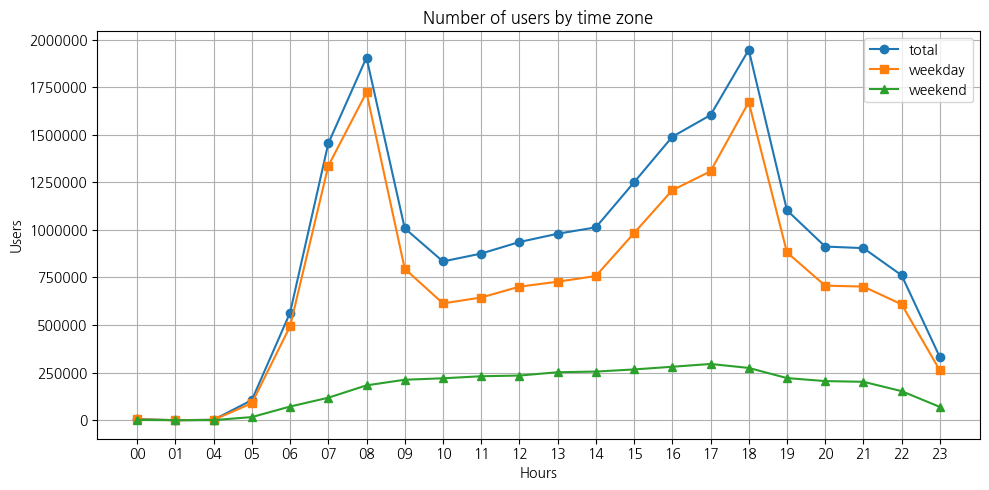

In [ ]:
# Group by boarding time and weekday/weekend,
hourly_usage = bus_df.groupby(['card_brd_tm', 'weekday_chk'], observed=False)['user_cnt'].sum().reset_index()
# then sum user counts, and then Pivot to make 'weekday' and 'weekend' into separate columns
hourly_usage = hourly_usage.pivot(index='card_brd_tm', columns='weekday_chk', values='user_cnt').fillna(0)

# Calculate total users per hour
hourly_total = hourly_usage.sum(axis=1).rename('total') # total = weekday + weekend

# Combine total, weekday, and weekend into one table
df_plot = pd.concat(
    [hourly_total, hourly_usage['weekday'], hourly_usage['weekend']],
    axis=1
).sort_index().reset_index().rename(columns={'card_brd_tm': 'hour'})

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(df_plot['hour'], df_plot['total'], label='total', marker='o')
plt.plot(df_plot['hour'], df_plot['weekday'], label='weekday', marker='s')
plt.plot(df_plot['hour'], df_plot['weekend'], label='weekend', marker='^')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Number of users by time zone')
plt.xlabel('Hours')
plt.ylabel('Users')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**(Daily & Monthly)**

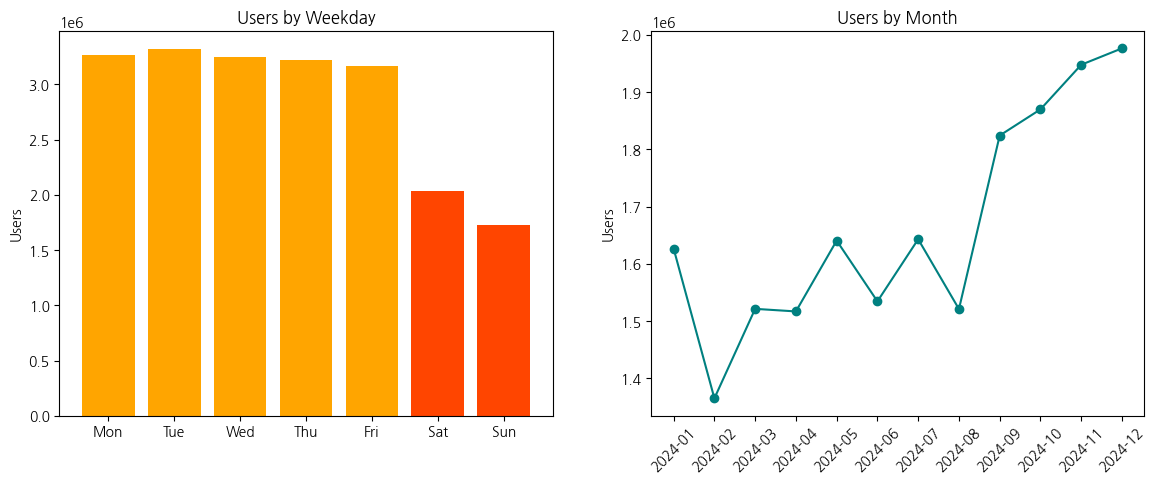

In [ ]:
# Daily grouping (group by date, weekday number, weekday type)
daily = bus_df.groupby(['brd_deal_dt', 'weekday_num', 'weekday_chk'], observed=True)['user_cnt'].sum().reset_index()

# Add year-month for monthly aggregation
daily['year_month'] = daily['brd_deal_dt'].dt.to_period('M')

# Aggregation monthly user counts
monthly = daily.groupby('year_month')['user_cnt'].sum().reset_index()

 # Aggregation by weekday number
label_map2 = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}


weekday_total = daily.groupby('weekday_num', observed=True)['user_cnt'].sum().reset_index().sort_values('weekday_num')
weekday_total['weekday_name'] = weekday_total['weekday_num'].map(label_map2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for users by weekday (left)
axs[0].bar(weekday_total['weekday_name'], weekday_total['user_cnt'], color=['orange']*5 + ['orangered']*2)
axs[0].set_title('Users by Weekday')
axs[0].set_ylabel('Users')

# Line chart for users by month (right)
axs[1].plot(monthly['year_month'].astype(str), monthly['user_cnt'], marker='o', color='teal')
axs[1].set_title('Users by Month')
axs[1].set_ylabel('Users')
axs[1].tick_params(axis='x', rotation=45)

# Adjust spacing between plots and display
plt.show()


# 3. Top bus routes

(merging with the route info file)

In [ ]:
rt_df.sample(5)

,route_code,route_num,route_name
113,60600321,91,(봉대리~조치원버스터미널)
299,60600133,655,(세종고속시외버스터미널~충남대학교)
296,60600136,NaN,NaN
136,60600298,204,(문화체육관광부~문화체육관광부)도서관방향
158,60600276,691,(세종고속시외버스터미널~송강마을아파트)


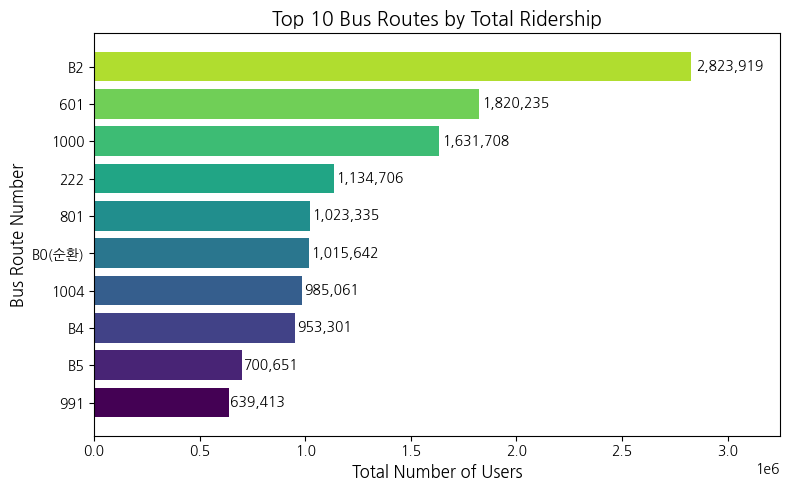

In [ ]:
# 1. Create a lightweight DataFrame with only necessary columns
light_bus_df = bus_df[["card_rout_cd", "user_cnt"]].copy()

# 2. Create a mapping dictionary: route_code → route_num
route_map = rt_df.set_index("route_code")["route_num"].to_dict()

# 3. Add route_num using map() (more memory-efficient than merge)
light_bus_df["route_num"] = light_bus_df["card_rout_cd"].map(route_map)

# 4. Aggregate total users by route number and sort by usage
route_usage = (
    light_bus_df
    .groupby("route_num", as_index=False)["user_cnt"]
    .sum()
    .sort_values(by="user_cnt", ascending=False)
)

# 5. Select top 10 routes
top_routes = route_usage.head(10)[::-1]

# 6. Visualization
colors = plt.cm.viridis(range(0, 256, int(256 / 10)))

plt.figure(figsize=(8, 5))
bars = plt.barh(top_routes["route_num"].astype(str), top_routes["user_cnt"], color=colors)

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height() / 2, f'{int(width):,}',
             va='center', ha='left', fontsize=10)

# (extending the x-axis range)
plt.xlim(0, top_routes["user_cnt"].max() * 1.15)

# Titles and axis labels
plt.title("Top 10 Bus Routes by Total Ridership", fontsize=14)
plt.ylabel("Bus Route Number", fontsize=12)
plt.xlabel("Total Number of Users", fontsize=12)
plt.tight_layout()
plt.show()

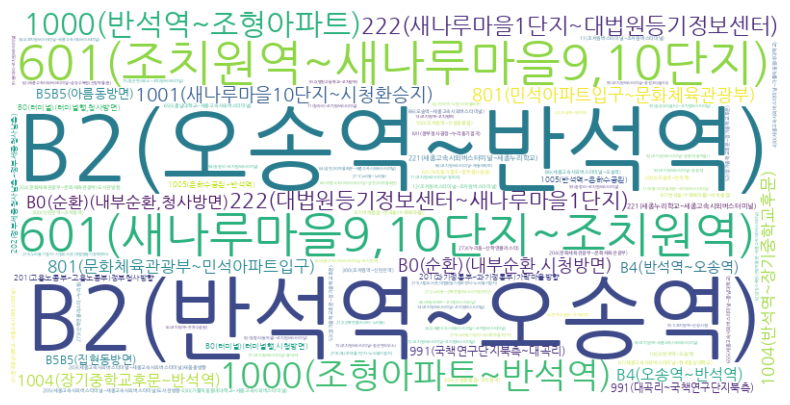

In [ ]:

# Group by bus route top20
route = bus_df.groupby(['card_rout_cd'])['user_cnt'].sum().reset_index()
route.rename(columns={'card_rout_cd': 'route_cd'}, inplace=True)
route.rename(columns={'user_cnt': 'users'}, inplace=True)
route = route.merge(rt_df, left_on='route_cd', right_on ='route_code',  how='left')
route = route[~route['route_num'].isnull()]

route = route.sort_values(by='users', ascending=False).head(100).reset_index(drop=True)
rout = route[['route_num','route_name','users']]
rout.loc[:, 'route_num'] = rout['route_num'] + rout['route_name']
rout = rout[['route_num','users']]
dict_rout = rout.set_index('route_num')['users'].to_dict()

# Wordcloud
wordcloud = WordCloud(font_path = font_path,background_color='white', width=800, height=400).generate_from_frequencies(dict_rout)

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


# 4. Top Bus Stops



In [ ]:
# Grouping by station
brd_sttn = bus_df.groupby(['card_brd_sttn_id'])['user_cnt'].sum().reset_index()
brd_sttn.rename(columns={'card_brd_sttn_id': 'sttn_id'}, inplace=True)
brd_sttn.rename(columns={'user_cnt': 'boarding_users'}, inplace=True)

alit_sttn = bus_df.groupby(['card_alit_sttn_id'])['user_cnt'].sum().reset_index()
alit_sttn.rename(columns={'card_alit_sttn_id': 'sttn_id'}, inplace=True)
alit_sttn.rename(columns={'user_cnt': 'alighting_users'}, inplace=True)

(Merging with the station info file)

In [ ]:
st_df.head()

,station_code,station_name,region_code,latitude,longitude,city_name,dong_name
0,6920075,조치원버스터미널,2901011.0,36.60200,127.302700,세종시,조치원읍
1,6910906,부강면,2901033.0,36.52986,127.366130,세종시,부강면
2,6910075,조치원버스터미널,2901011.0,36.60200,127.302700,세종시,조치원읍
3,6906766,국립박물관단지,2901031.0,36.49000,127.272418,세종시,나성동
4,6906582,이응다리(금강보행교),2901031.0,36.48630,127.282561,세종시,나성동


In [ ]:
# Total number of passengers boarding and disembarking per stop (if there are multiple stops with the same name, they are treated as one)

# Ensure type consistency for merging
st_df['station_code'] = st_df['station_code'].astype(str)

# Merge boarding and alighting user data on station ID
sttn = brd_sttn.merge(alit_sttn, on='sttn_id', how='left')

# Calculate total users (boarding + alighting) for each station
sttn['total_users'] = sttn['boarding_users'] + sttn['alighting_users']

# Merge with station information to get station names and coordinates
sttn = sttn.merge(st_df, left_on='sttn_id', right_on='station_code', how='left')

# Sort stations by total user count in descending order
sttn = sttn.sort_values(by='total_users', ascending=False)

# Group by station name (treating stations with the same name as one), aggregate user counts and take the first latitude/longitude
sttn_t20 = sttn.groupby(['station_name']).agg({
    'boarding_users': 'sum',
    'alighting_users': 'sum',
    'total_users': 'sum',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Sort by total users and select the top 20 stations
sttn_t20 = sttn_t20.sort_values(by='total_users', ascending=False).head(20).reset_index(drop=True)

from IPython.display import display
top20 = sttn_t20.drop(columns=['latitude', 'longitude'])

# Convert index to ranking (start from 1)
top20.reset_index(drop=True, inplace=True)
top20.index = sttn_t20.index + 1  # start from 1

# Style the table for display
styled_table = top20.style \
    .format({
        "boarding_users": "{:,.0f}",
        "alighting_users": "{:,.0f}",
        "total_users": "{:,.0f}"
    }) \
    .bar(subset=["total_users"], color="#FFADAD") \
    .set_caption("🚌 Top 20 Bus Stops by Usage") \
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"), ("font-weight", "bold"), ("color", "#333")]},
        {"selector": "th.col_heading.level0.col3",  # column header (th)
         "props": [("min-width", "300px")]},
        {"selector": "td.col3",  # column content (td)
         "props": [("min-width", "300px")]}
    ])

# Display the styled table
display(styled_table)


,station_name,boarding_users,alighting_users,total_users
1,반석역,"1,455,178","1,540,229","2,995,407"
2,오송역,"805,588","814,632","1,620,220"
3,정부세종청사북측,"598,355","549,073","1,147,428"
4,정부세종청사남측,"574,679","539,713","1,114,392"
5,도담동(도램마을),"535,347","451,062","986,409"
6,조치원역,"551,380","410,047","961,427"
7,도담동,"521,187","420,217","941,404"
8,"해밀동,산울동","509,246","398,304","907,550"
9,세종고속시외버스터미널,"440,635","414,964","855,599"
10,"시청,시의회,교육청,세무서","423,838","387,588","811,426"


In [ ]:
import plotly.express as px

fig = px.scatter_mapbox(
    sttn_t20,
    lat="latitude",
    lon="longitude",
    size="total_users",
    color="boarding_users",
    color_continuous_scale=[
        (0.0, "#ffe066"),
        (0.5, "#ff8000"),
        (1.0, "#cc0000")
    ],
    hover_name="station_name",
    hover_data={
        "boarding_users": True,
        "alighting_users": True,
        "total_users": True
    },
    size_max=50,
    zoom=10,
    mapbox_style="carto-positron",
    title="Top 20 Bus Stops by Usage (Interactive bubble map)"
)

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Boarding Users (Color) / Total Users (Size)",
    coloraxis_colorbar=dict(
        title="Boarding Users",
        thickness=20,
        len=0.75
    )
)

fig.show()

fig.write_html("/content/drive/MyDrive/Python/Python project(Sejong bus)_20250429_fullplot.html",
               full_html=True, include_plotlyjs='cdn')

# 5. District-Level Analysis (efficiency, correlation)

**(1) Analyzing the efficiency of bus stops**

(a) bus users for each district

In [ ]:
# 1. Filter bus stops located in Sejong City
station_codes = st_df[st_df['city_name'] == '세종시']['station_code'].unique()
used_station_codes = bus_df['card_brd_sttn_id'].unique()
sejong_station_codes = [code for code in station_codes if code in used_station_codes]

# 2. Filter only boarding records to avoid duplication
light_bus_df = bus_df[bus_df['card_brd_sttn_id'].isin(sejong_station_codes)][['card_brd_sttn_id', 'user_cnt']].copy()

# 3. Prepare mapping from station code to district (dong) name
dong_map = st_df.set_index('station_code')['dong_name'].to_dict()

# 4. Add district (dong) name to each bus usage record
light_bus_df['dong_name'] = light_bus_df['card_brd_sttn_id'].map(dong_map)

# 5. Aggregate total users by district
summary = light_bus_df.groupby('dong_name')['user_cnt'].sum().reset_index()
summary.columns = ['dong_name', 'total_users']

# 6. Sort districts by total users in descending order
summary = summary.sort_values(by='total_users', ascending=False)

In [ ]:
print(summary)

   dong_name  total_users
20      조치원읍      2084817
13       어진동      2060613
2        나성동      1760992
5        도담동      1490817
6        반곡동      1083013
0        고운동      1079400
4        대평동      1006806
12       아름동       773017
10       소담동       711003
22       한솔동       636042
7        보람동       599827
23       해밀동       584127
21       종촌동       541973
3        다정동       468711
9        새롬동       454627
1        금남면       329636
17       장군면       293710
16       연서면       202650
19       전의면       134944
8        부강면       130923
14       연기면       109634
18       전동면        84087
15       연동면        67798
11       소정면        26264


In [ ]:
# Style the full table for all districts
styled_summary = summary.style \
    .hide(axis="index") \
    .format({
        "total_users": "{:,.0f}"
    }) \
    .bar(subset=["total_users"], color="#AEDFF7") \
    .set_caption("🚌 Top 15 Districts by Bus Ridership in Sejong City in 2024") \
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "18px"), ("font-weight", "bold"), ("color", "#333")]},
        {"selector": "th.col_heading.level0.col1",
         "props": [("min-width", "200px")]},
        {"selector": "td.col1",
         "props": [("min-width", "200px")]}
    ])

#  Display the styled table
# from IPython.display import display
# display(styled_summary)

# Instead of displaying the first table immediately,
# creating another table below,
# and then displaying both tables side by side (horizontally).

(b) bus stops for each district

In [ ]:
# #1. Filter bus stops located in Sejong City (reusing the code above)
# sejong_station_codes = st_df[st_df['city_name'] == '세종시']['station_code'].unique()

# 2. Count the number of station codes by district (dong_name)
# Aggregate the number of bus stops per district using sejong_station_codes
station_count_by_dong = (
    st_df[st_df['station_code'].isin(sejong_station_codes)]
    .groupby('dong_name')['station_code']
    .nunique()
    .reset_index()
    .rename(columns={'station_code': 'num_stations'})
    .sort_values(by='num_stations', ascending=False)
)

In [ ]:
styled_station_count = station_count_by_dong.style \
    .hide(axis="index") \
    .format({"num_stations": "{:,.0f}"}) \
    .bar(subset=["num_stations"], color="#FFD580") \
    .set_caption("🚌 Number of Bus Stations by District in Sejong City") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"),("font-weight", "bold")]}
    ])

# from IPython.display import display
# display(styled_station_count)

In [ ]:
# Display two styled tables side by side using HTML
# (This places Table A and Table B next to each other horizontally)

from IPython.display import display, HTML

display(HTML(f"""
<div style="display: flex; gap: 40px;">
    <div>{styled_summary.to_html()}</div>
    <div>{styled_station_count.to_html()}</div>
</div>
"""))

dong_name,total_users
조치원읍,"2,084,817"
어진동,"2,060,613"
나성동,"1,760,992"
도담동,"1,490,817"
반곡동,"1,083,013"
고운동,"1,079,400"
대평동,"1,006,806"
아름동,"773,017"
소담동,"711,003"
한솔동,"636,042"


In [ ]:
# Ensure naming consistency for merging
filtered_station_count = station_count_by_dong.copy()

# Merge bus usage summary with station count data
usage_station_df = pd.merge(
    summary,
    filtered_station_count,
    on='dong_name',
    how='inner'
)

# Calculate users per bus stop
usage_station_df['users_per_station'] = usage_station_df.apply(
    lambda row: row['total_users'] / row['num_stations'] if row['num_stations'] > 0 else 0,
    axis=1
)

# Sort by users per station in descending order
usage_station_df = usage_station_df.sort_values(by='users_per_station', ascending=False)

# Apply styling
styled_usage_station = usage_station_df.style \
    .hide(axis="index") \
    .format({
        "total_users": "{:,.0f}",
        "num_stations": "{:,.0f}",
        "users_per_station": "{:,.2f}"
    }) \
    .bar(subset=["users_per_station"], color="#FFA07A") \
    .set_caption("🚏 Bus Users per Station by District (Dong)") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "bold")]}
    ])

# Display the styled table
from IPython.display import display
display(styled_usage_station)


dong_name,total_users,num_stations,users_per_station
도담동,"1,490,817",32,"46,588.03"
대평동,"1,006,806",23,"43,774.17"
나성동,"1,760,992",42,"41,928.38"
어진동,"2,060,613",54,"38,159.50"
아름동,"773,017",23,"33,609.43"
다정동,"468,711",14,"33,479.36"
보람동,"599,827",21,"28,563.19"
소담동,"711,003",26,"27,346.27"
종촌동,"541,973",20,"27,098.65"
고운동,"1,079,400",49,"22,028.57"


In [ ]:
import json

# 1. Total bus users per district (dong) in Sejong City
summary = pd.DataFrame({
    'dong_name': [
        '조치원읍', '어진동', '나성동', '도담동', '반곡동', '고운동', '대평동', '아름동',
        '소담동', '한솔동', '보람동', '해밀동', '종촌동', '다정동', '새롬동', '금남면',
        '장군면', '연서면', '전의면', '부강면', '연기면', '전동면', '연동면', '소정면'
    ],
    'total_users': [
        2084817, 2060613, 1760992, 1490817, 1083013, 1079400, 1006806, 773017,
        711003, 636042, 599827, 584127, 541973, 468711, 454627, 329636,
        293710, 202650, 134944, 130923, 109634, 84087, 67798, 26264
    ]
})

# 2. Count number of bus stops per dong (remove duplicates using station_code)
st_df = pd.read_csv(f_path2, encoding="euc-kr").drop_duplicates(subset='station_code')
station_count_by_dong = st_df[st_df['city_name'] == '세종시']['dong_name'].value_counts().reset_index()
station_count_by_dong.columns = ['dong_name', 'num_stations']

# 3. Merge usage data with station counts and calculate users per station
usage_station_df = pd.merge(summary, station_count_by_dong, on='dong_name', how='inner')
usage_station_df['users_per_station'] = usage_station_df.apply(
    lambda row: row['total_users'] / row['num_stations'] if row['num_stations'] > 0 else 0,
    axis=1
)

# 4. Prepare data for choropleth visualization
choropleth_df = usage_station_df[['dong_name', 'users_per_station']].copy()

# 5. Load and filter GeoJSON to include only Sejong City
with open( f_folder + "HangJeongDong_ver20250401.geojson", encoding='utf-8') as f: # Check your file path !!
    geojson_data = json.load(f)

# Extract features only for Sejong City and assign dong_name
sejong_features = []
for feature in geojson_data['features']:
    if '세종특별자치시' in feature['properties']['adm_nm']:
        dong_name = feature['properties']['adm_nm'].split()[-1]
        feature['properties']['dong_name'] = dong_name
        sejong_features.append(feature)

sejong_geojson = {
    "type": "FeatureCollection",
    "features": sejong_features
}

# 6. Initialize base Folium map centered on Sejong with adjusted zoom
m = folium.Map(
    location=[36.55, 127.3],
    zoom_start=11,  # ← Adjusted from 12 to 11 for a more zoomed-out view
    tiles='cartodbpositron',
    width='70%',
    height=550
)

# 7. Draw choropleth layer showing users per station by dong
folium.Choropleth(
    geo_data=sejong_geojson,
    name='Users per Station (All Dongs)',
    data=choropleth_df,
    columns=['dong_name', 'users_per_station'],
    key_on='feature.properties.dong_name',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.5,
    nan_fill_color='white',
    legend_name='Bus Users per Station',
    highlight=True
).add_to(m)

# 8. Add tooltip showing dong name
folium.GeoJsonTooltip(
    fields=['dong_name'],
    aliases=['District:'],
    localize=True
).add_to(folium.GeoJson(sejong_geojson).add_to(m))

# 9. Display the map
m

# ★When you move your mouse over an area, the name of each district appears in Korean.★


**(2) Correlation with various regional factors**

In [ ]:
info_df = pd.read_csv(f_path6, encoding='euc-kr')

# Rename columns
info_df.columns = [
    'dong_name',                         # Name of administrative district (eup/myeon/dong)
    'one_person_households',            # Number of one-person households
    'population_over_65',               # Population aged 65 and over
    'population_under_18',              # Population aged under 18
    'population',                       # Total population
    'registered_vehicles',              # Number of registered vehicles
    'registered_electric_vehicles'      # Number of registered electric vehicles
]

# Remove whitespace for cleaner merging (Stripping whitespace prevents hidden data mismatches and ensures reliable merging.)
info_df['dong_name'] = info_df['dong_name'].str.strip()

# Merge with bus usage summary data
merged_df = pd.merge(summary, info_df, on='dong_name', how='inner')

# Select variables for correlation analysis
selected_vars = merged_df[[
    'total_users',
    'one_person_households',
    'population_over_65',
    'population_under_18',
    'population',
    'registered_vehicles',
    'registered_electric_vehicles'
]]

# Compute Pearson correlation matrix
correlation_matrix = selected_vars.corr(method='pearson')

# Display results
print("✅ Correlation Analysis Result:")
print(correlation_matrix[['total_users']].sort_values(by='total_users', ascending=False))

✅ Correlation Analysis Result:
                              total_users
total_users                      1.000000
one_person_households            0.655265
population_under_18              0.571493
population                       0.557058
registered_vehicles              0.514593
registered_electric_vehicles     0.444200
population_over_65               0.352671


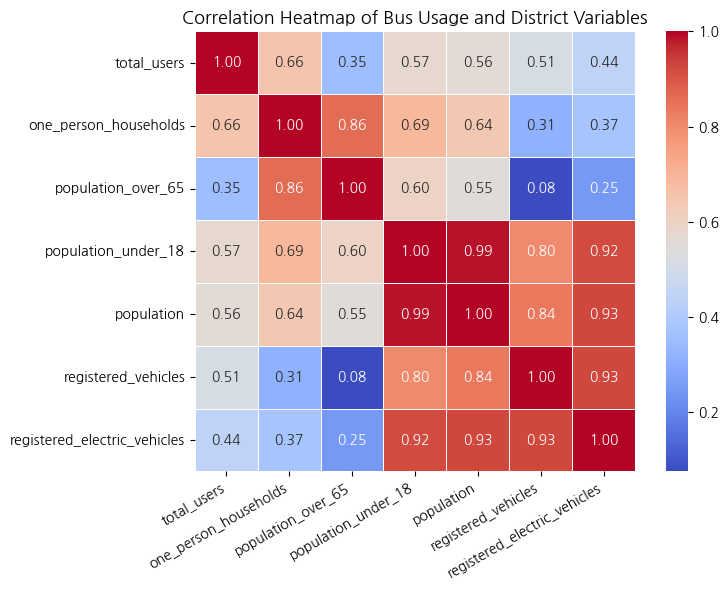

In [ ]:
# Create a figure and set its size
plt.figure(figsize=(8, 6))

# Draw the correlation heatmap
sns.heatmap(
    correlation_matrix,     # Data to visualize
    annot=True,             # Show correlation coefficients
    fmt=".2f",              # Format numbers to 2 decimal places
    cmap="coolwarm",        # Color palette
    linewidths=0.5,         # Line width between cells
    square=True             # Force square-shaped cells
)

# Set title of the plot
plt.title("Correlation Heatmap of Bus Usage and District Variables", fontsize=13, weight='bold')

# Adjust x-axis and y-axis label angles and fonts
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Optimize layout to prevent clipping
plt.tight_layout()

# Show the heatmap
plt.show()


# 6. Relationship between bus usage and weather & air quality

In [ ]:
# Grouping daily bus usage by date and weekday
daily = bus_df.groupby(['brd_deal_dt', 'weekday_num', 'weekday_chk'], observed=True)['user_cnt'].sum().reset_index()

# Create year-month column
daily['year_month'] = daily['brd_deal_dt'].dt.to_period('M')

In [ ]:
wt_df.head()

,date,temp_avg,temp_min,temp_max,rainfall
0,2024-01-01,3.4,0.2,7.3,NaN
1,2024-01-02,3.7,1.3,6.2,NaN
2,2024-01-03,2.1,-0.7,5.6,0.9
3,2024-01-04,0.9,-4.6,6.9,NaN
4,2024-01-05,4.8,1.1,10.2,NaN


In [ ]:
# Merge with weather data
corr1 = daily.merge(wt_df, left_on='brd_deal_dt', right_on='date', how='left')

# Exclude weekends and select variables
corr1 = corr1[corr1['weekday_chk'] != 'weekend']
corr1 = corr1[['date', 'user_cnt', 'temp_avg', 'temp_min', 'temp_max', 'rainfall']]

# Fill NA with 0
corr1 = corr1.fillna(0)

# Merge with fine dust data
corr1 = corr1.merge(fd_df, on='date', how='left')

# Drop unused column
corr1 = corr1.drop('point', axis=1)


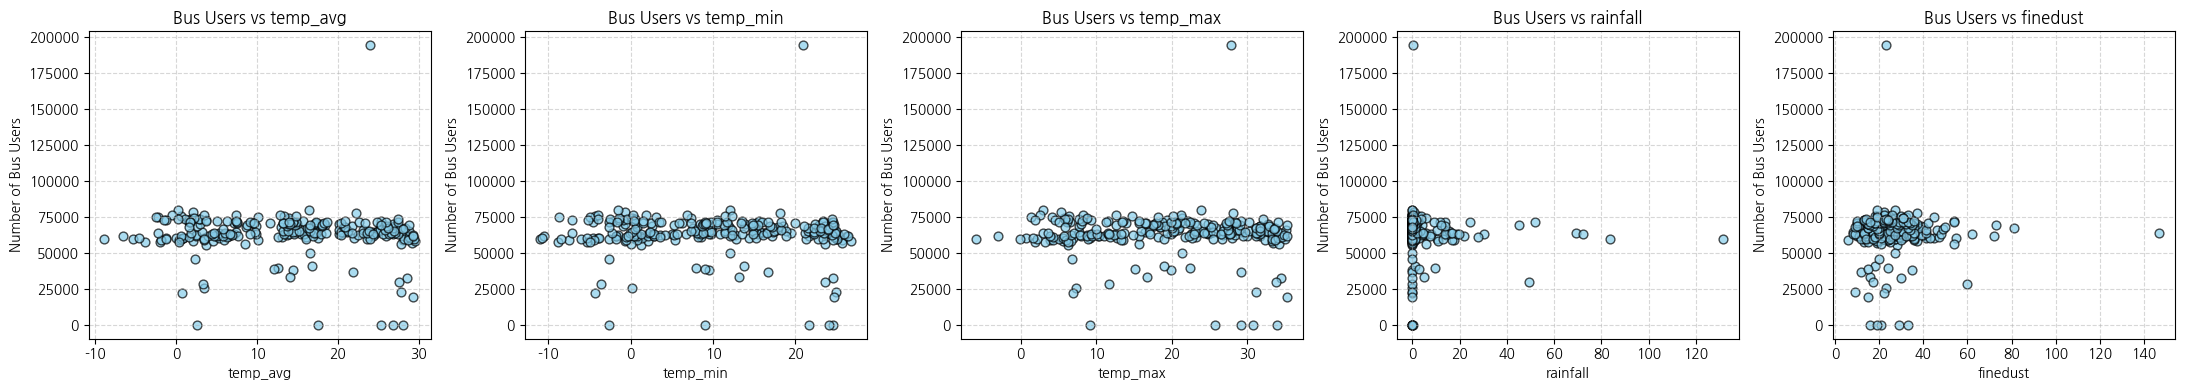

In [ ]:
# Create subplots (slightly wider layout)
fig, axs = plt.subplots(1, 5, figsize=(22, 4))

# Variables to compare with bus usage
cols = ['temp_avg', 'temp_min', 'temp_max', 'rainfall', 'finedust']

# Draw scatter plots
for i, col in enumerate(cols):
    axs[i].scatter(
        corr1[col], corr1['user_cnt'],
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
        s=40
    )
    axs[i].set_title(f'Bus Users vs {col}', fontsize=12, weight='bold')
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Number of Bus Users', fontsize=10)
    axs[i].grid(True, linestyle='--', alpha=0.5)

# Auto layout adjustment
plt.tight_layout()
plt.show()


In [ ]:
#. ipynb → html
!jupyter nbconvert --to html "/content/drive/MyDrive/Python/Python project(Sejong bus)_20250429.ipynb" --log-level ERROR

#. download the converted html file
from google.colab import files
files.download("/content/drive/MyDrive/Python/Python project(Sejong bus)_20250429.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>